### Baselines

We start by evaluating the baseline models (3-NN and convolutional 1-NN) on the validation set.

In [ ]:
import sys
sys.path.append("..")


import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
from src.data import NiiPoint
from src.processing import CONSTANTS
from src.architectures import NiiKNN, NiiCKNN
        
test_path_img = os.path.join("../", CONSTANTS.NORM_DATA_PATH, f"imagesVl/")
test_path_label = os.path.join("../", CONSTANTS.NORM_DATA_PATH, f"labelsVl/")

train_path_img = os.path.join("../", CONSTANTS.NORM_DATA_PATH, "imagesTr")
train_path_label = os.path.join("../", CONSTANTS.NORM_DATA_PATH, "labelsTr")

target_path_label_cknn = os.path.join("../data/Predictions_val/images_norm_cknn/")
target_path_label_knn = os.path.join("../data/Predictions_val/images_norm_knn/")

os.makedirs(target_path_label_cknn, exist_ok=True)
os.makedirs(target_path_label_knn, exist_ok=True)

for file_path in os.listdir(test_path_img):
    file_id = file_path[:9]
    img_path = os.path.join(test_path_img, file_path)
    lab_path = os.path.join(test_path_label, f"{file_id}_0001.nii.gz")
    x = NiiPoint.from_path(img_path, "cuda")
    y = NiiPoint.from_path(lab_path, "cuda")


    if False:
        model = NiiKNN(3, train_path_img, train_path_label, max_num=100)
        x_pred, y_pred = model(x)
        y_pred.save_to_path(os.path.join(target_path_label_knn, f"{file_id}_0001.nii.gz"))
        print(f"Predicted label for {file_id} saved to {os.path.join(target_path_label_knn, f'{file_id}_0001.nii.gz')}")
        
    if True:
        fs = 5
        model = NiiCKNN(3, (fs, fs, fs), train_path_img, train_path_label, max_num=4, max_batch=15)
        x_pred, y_pred = model(x)
        y_pred.save_to_path(os.path.join(target_path_label_cknn, f"{file_id}_0001.nii.gz"))
        print(f"Predicted label for {file_id} saved to {os.path.join(target_path_label_cknn, f'{file_id}_0001.nii.gz')}")

/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/nibabel/optpkg.py:104: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  pkg = __import__(name, fromlist=fromlist)
/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    The plotting functions break depending on versions of torch and monai, and backend for nii loading.
    They are still useful, but become heavily distorted if the nii loading backend is not set to nibabel. 
    If you see distorted plots, try setting the environment variable:
    
Predicted label for case_0010 saved to ../data/Predictions_val/images_norm_knn/case_0010_0001.nii.gz
Predicted label for case_0156 saved to ../data/Predictions_val/images_norm_knn/case_0156_0001.nii.gz
Predicted label for case_0136 saved to ../data/Predictions_val/images_norm_knn/case_0136_0001.nii.gz
Predicted label for case_0066 saved to ../data/Predictions_val/images_norm_knn/case_0066_0001.nii.gz
Predicted label for case_0014 saved to ../data/Predictions_val/images_norm_knn/case_0014_0001.nii.gz
Predicted label for case_0089 saved to ../data/Predictions_val/images_norm_knn/case_0089_0001.nii.gz
Predicted label for case_0019 saved to ../data/Predictions_val/images_norm_knn/case_0019_0001.nii.gz
Predic

#### DURAG on Validation set

We evaluate DURAG on the validation and the hold-out test set. Since DURAG evaluates on 64 x 128 x 128 slices, we need to
* Crop and interpolate the data before evaluation, and
* Upscale and pad the data after evaluation.

In [1]:
import os
import torch
import sys
sys.path.append("..")
from src.architectures import DURAG, NeighborLoader
from src.processing import CONSTANTS
from src.data import create_val_loader_and_saver, plot_slices

checkpointed_epoch = 500
size = 128
channels = 64 # Number of slices per chunk; must be divisible by 32 for SwinUNET
neighbor_count = 3
save_path = "../checkpoints/"

neighbor_loader = NeighborLoader(
    image_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_INP}",
    label_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_OUT}",
    channels = channels, # Number of slices per chunk
    neighbors = neighbor_count, # Number of nearest-neighbor feature maps
    device = "cuda",
    size = size,
    coarse_size = 32,
    include_neighbor_inputs = True,
)

val_loader, val_saver = create_val_loader_and_saver(
    image_dir=f"../{CONSTANTS.NORM_DATA_PATH_VAL_INP}",
    label_dir=f"../{CONSTANTS.NORM_DATA_PATH_VAL_OUT}",
    output_dir=f"../data/Predictions_val/images_norm_durag/",
    channels=channels,
    size=size,
    batch_size=1,
)

durag = DURAG.init_large_durag(neighbor_loader, dropout=0.3)
state_dict = torch.load(f"{save_path}epoch_{checkpointed_epoch}.pt")

# Distinguish between inner net and outer net for checkpointing
# DURAG wrapper state_dict keys: net.*, inner UNet state_dict keys: model.*
if all(k.startswith("net.") for k in state_dict.keys()):
    missing, unexpected = durag.load_state_dict(state_dict, strict=False)
    print(f"Loaded DURAG-wrapper checkpoint. Missing={len(missing)} Unexpected={len(unexpected)}")
else:
    missing, unexpected = durag.net.load_state_dict(state_dict, strict=False)
    print(f"Loaded inner-UNet checkpoint. Missing={len(missing)} Unexpected={len(unexpected)}")

durag.eval()

for i, batch in enumerate(val_loader):
    single = batch[0]

    with torch.no_grad():
        x = single["input"].to("cuda")[None, ...]
        y_pred = durag((x, None))
        val_saver.save(y_pred, single["inverse_meta"])

/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/nibabel/optpkg.py:104: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.2)
  pkg = __import__(name, fromlist=fromlist)
/home/emastr/github/aipek_task_2026/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    The plotting functions break depending on versions of torch and monai, and backend for nii loading.
    They are still useful, but become heavily distorted if the nii loading backend is not set to nibabel. 
    If you see distorted plots, try setting the environment variable:
    
Loaded neighbor cache: .neighbor_cache/neighbor_cache_8ee43ef9e7565319.pt
Loaded inner-UNet checkpoint. Missing=0 Unexpected=0


### DURAG on Test Set

Loaded neighbor cache: .neighbor_cache/neighbor_cache_8ee43ef9e7565319.pt
Loaded inner-UNet checkpoint. Missing=0 Unexpected=0


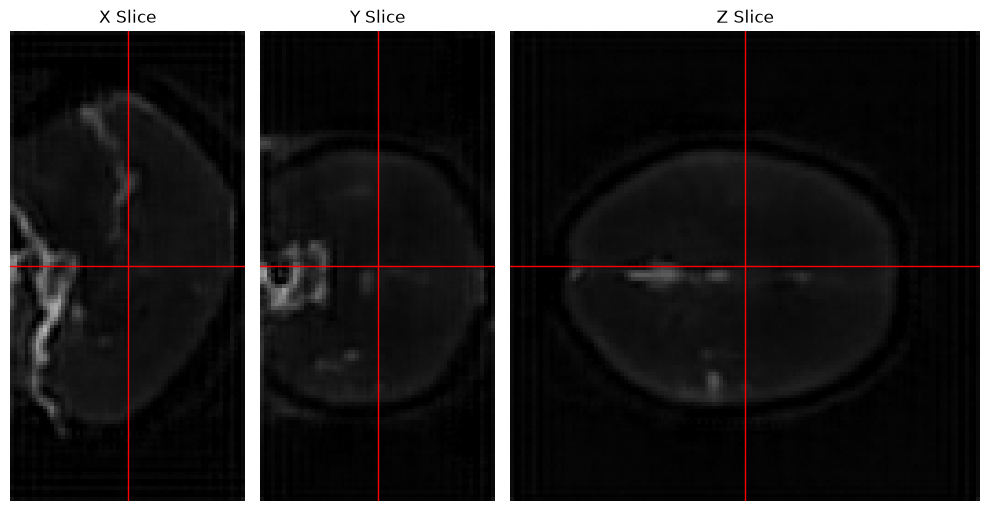

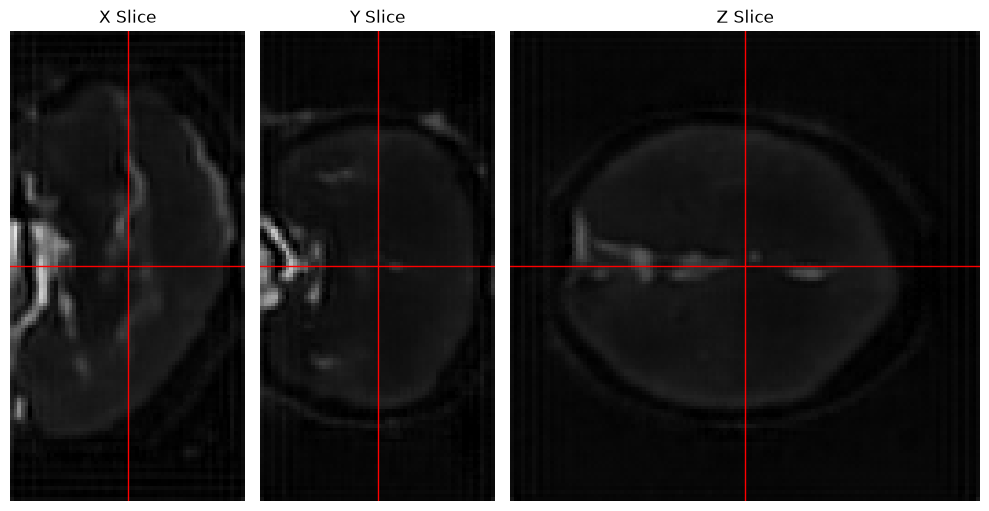

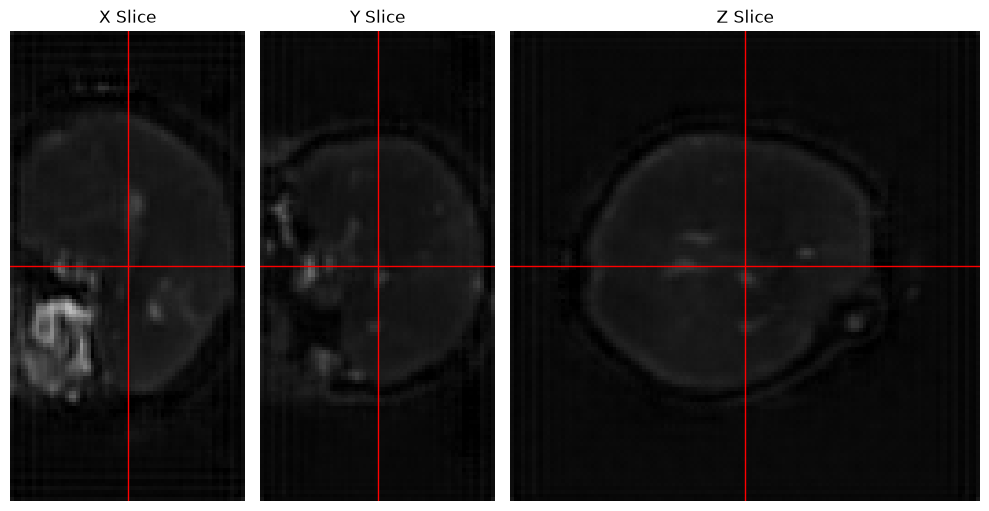

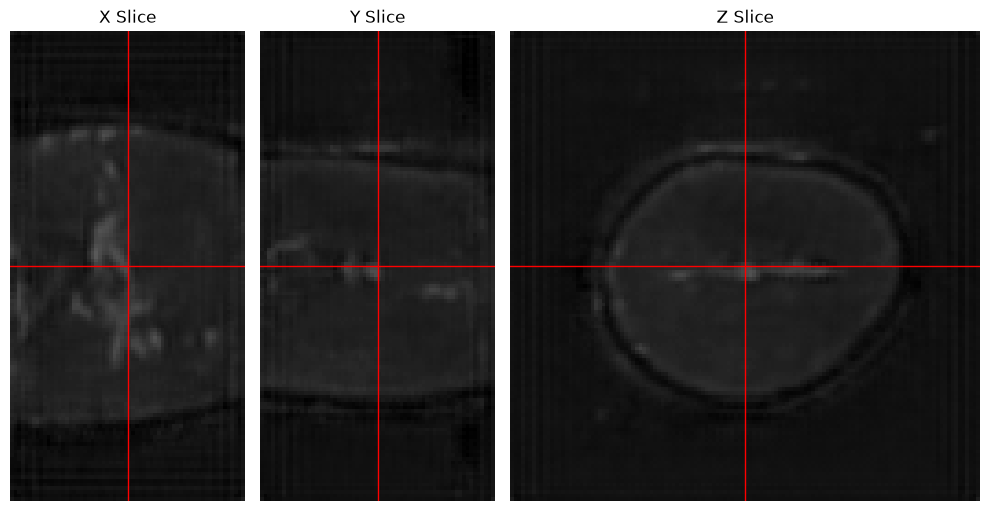

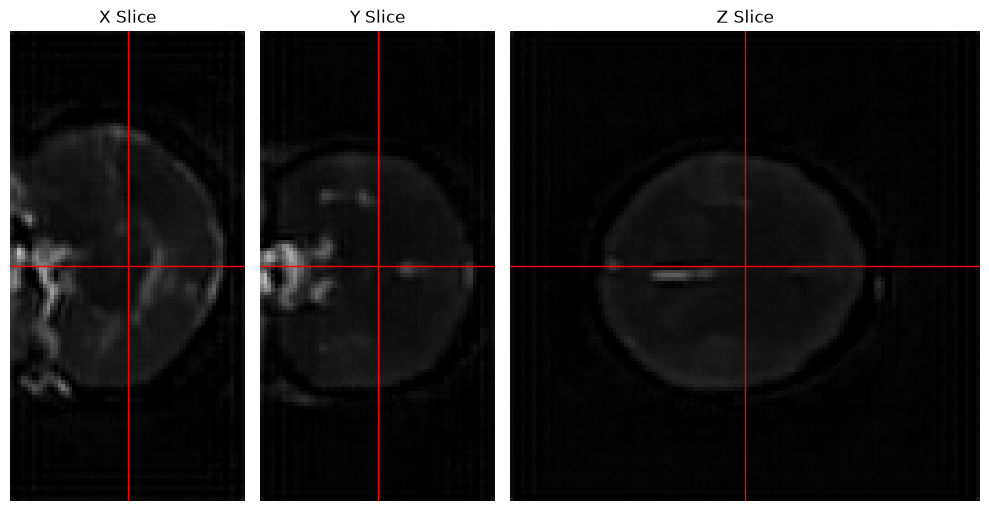

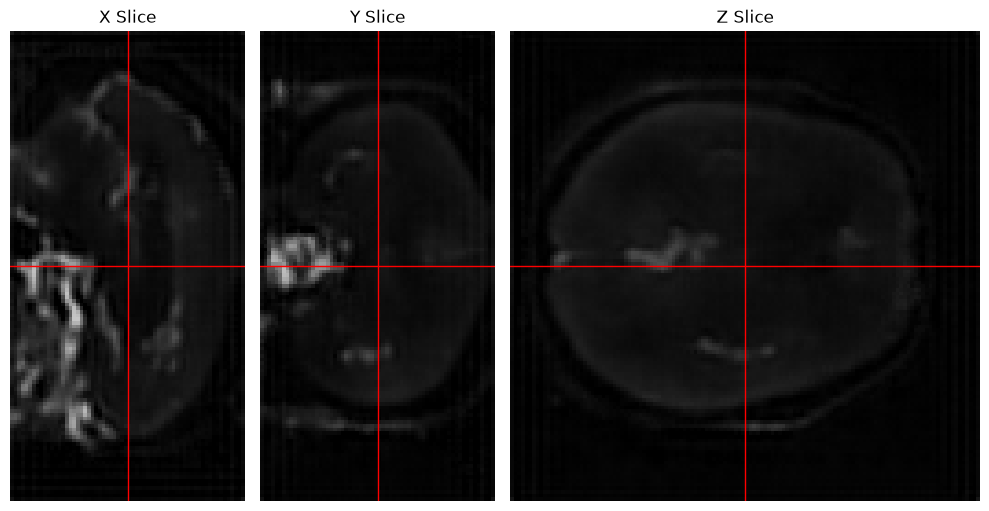

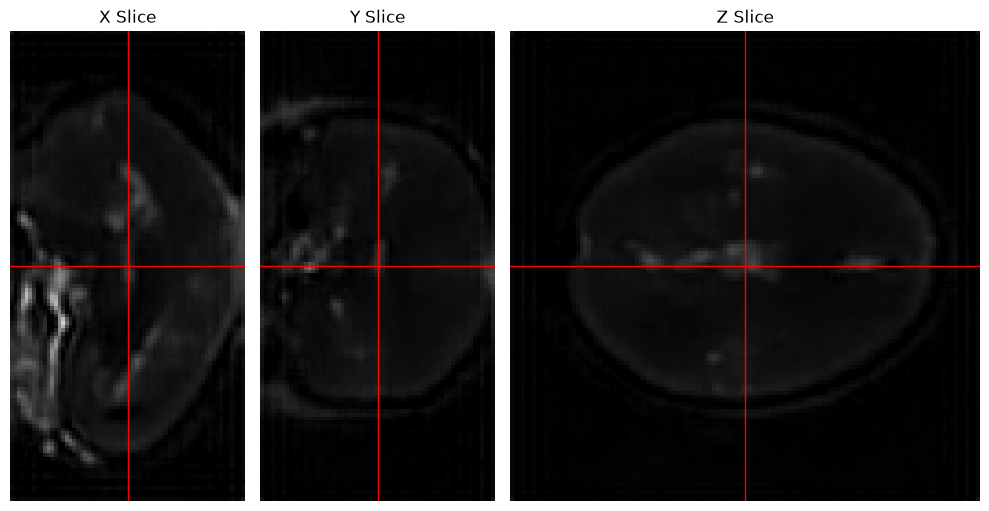

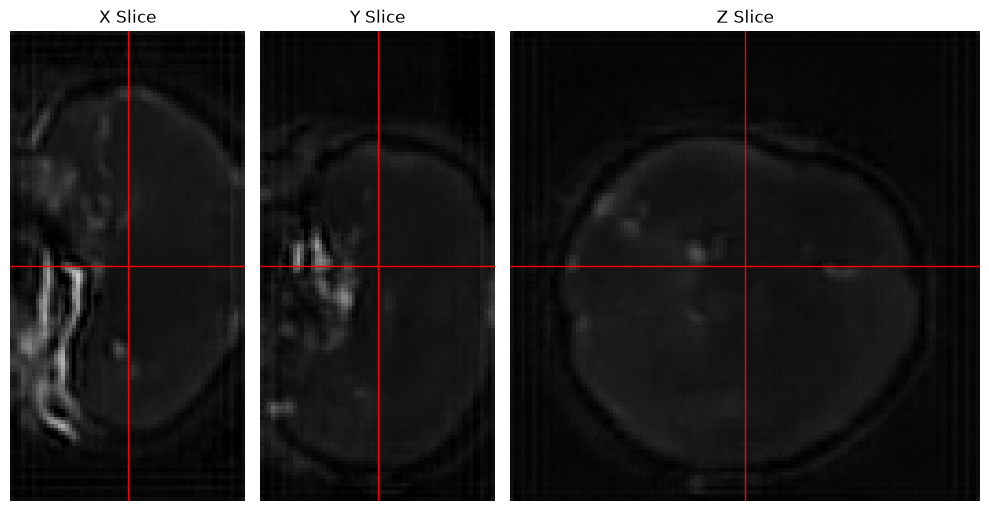

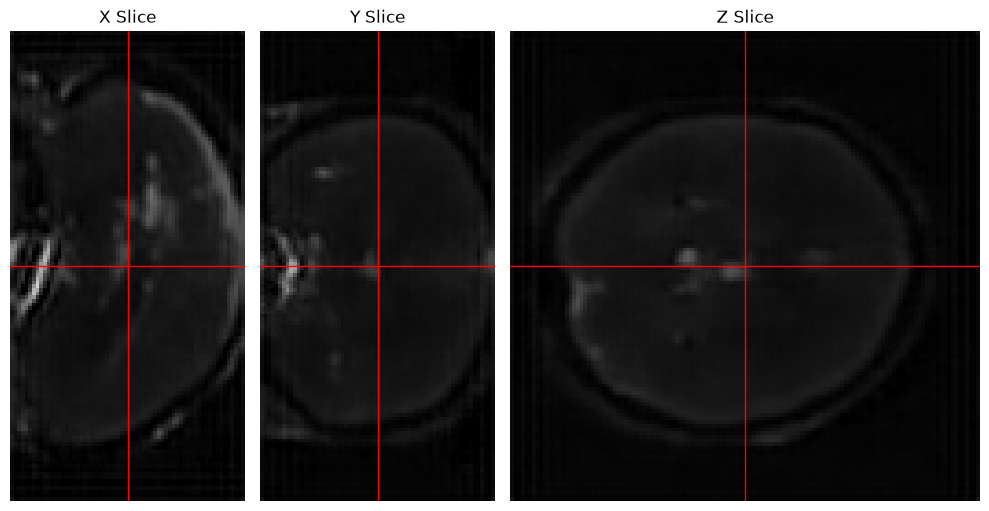

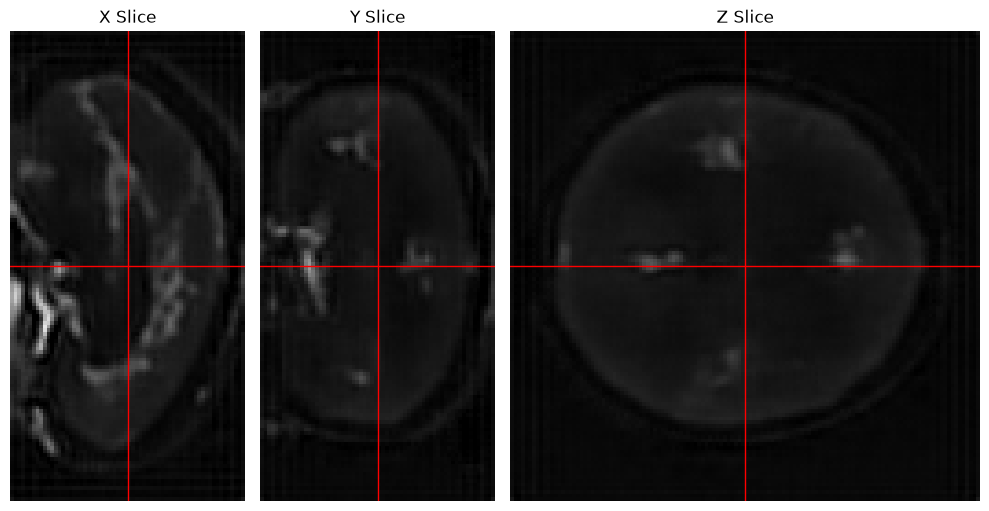

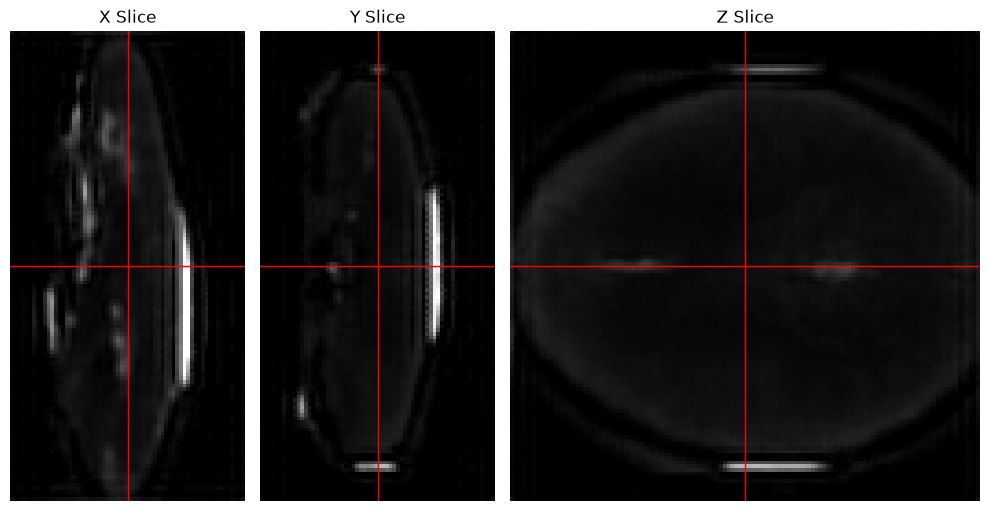

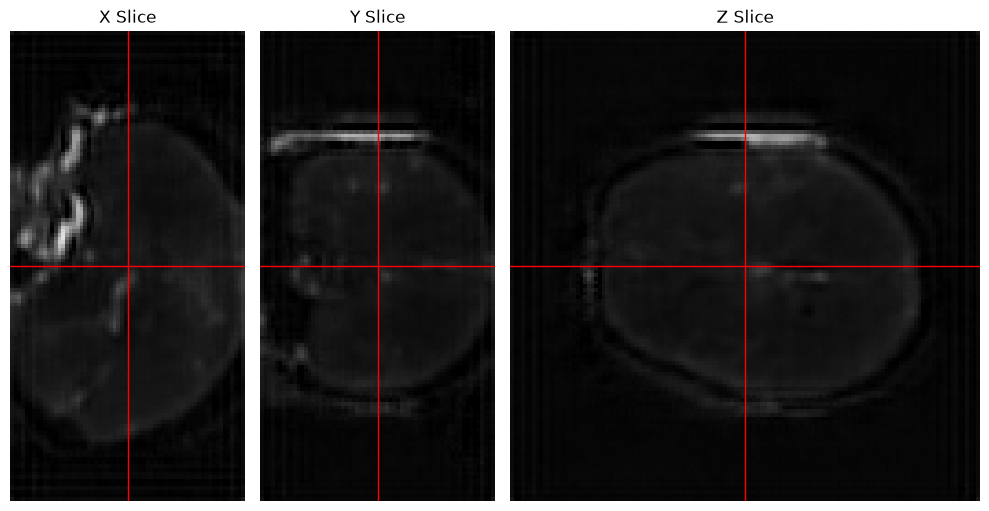

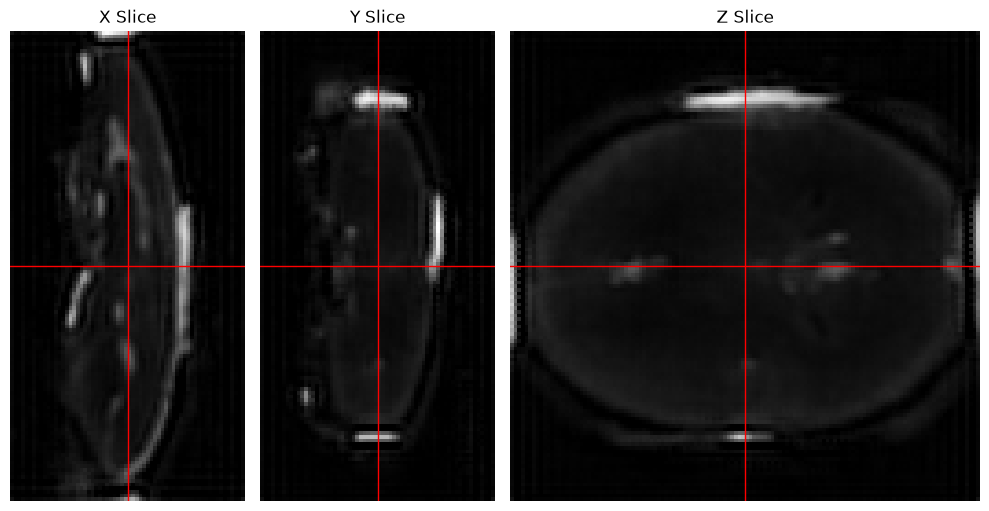

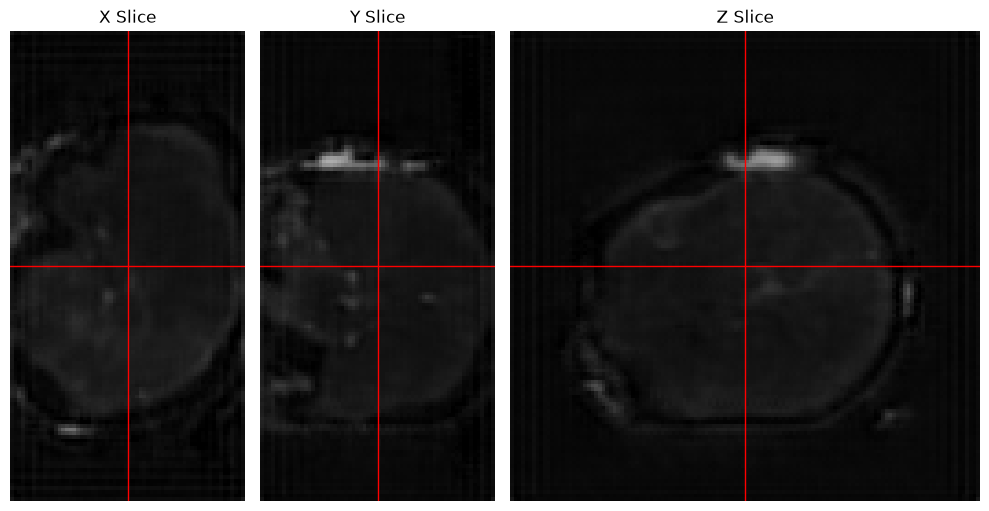

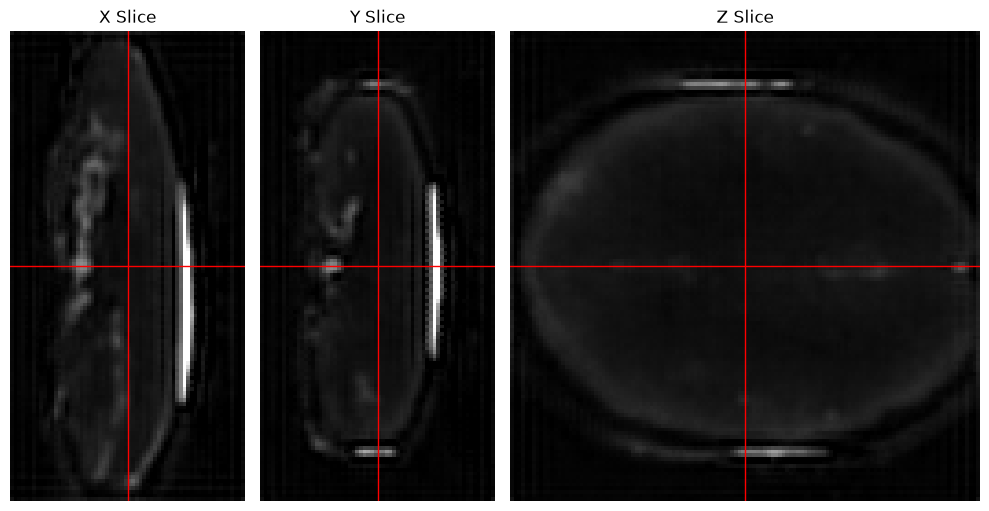

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import torch
import sys
sys.path.append("..")
from src.architectures import DURAG, NeighborLoader
from src.processing import CONSTANTS
from src.data import create_val_loader_and_saver, plot_slices

checkpointed_epoch = 500
size = 128
channels = 64 # Number of slices per chunk; must be divisible by 32 for SwinUNET
neighbor_count = 3
save_path = "../checkpoints/"

neighbor_loader = NeighborLoader(
    image_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_INP}",
    label_dir = f"../{CONSTANTS.NORM_DATA_PATH_TRAIN_OUT}",
    channels = channels, # Number of slices per chunk
    neighbors = neighbor_count, # Number of nearest-neighbor feature maps
    device = "cuda",
    size = size,
    coarse_size = 32,
    include_neighbor_inputs = True,
)

val_loader, val_saver = create_val_loader_and_saver(
    image_dir=f"../{CONSTANTS.NORM_DATA_PATH_TEST_INP}",
    label_dir=f"../{CONSTANTS.NORM_DATA_PATH_TEST_OUT}",
    output_dir=f"../{CONSTANTS.TEST_PRED_PATH}images_norm_durag/",
    channels=channels,
    size=size,
    batch_size=1,
)

durag = DURAG.init_large_durag(neighbor_loader, dropout=0.3)
state_dict = torch.load(f"{save_path}epoch_{checkpointed_epoch}.pt")

# Distinguish between inner net and outer net for checkpointing
# DURAG wrapper state_dict keys: net.*, inner UNet state_dict keys: model.*
if all(k.startswith("net.") for k in state_dict.keys()):
    missing, unexpected = durag.load_state_dict(state_dict, strict=False)
    print(f"Loaded DURAG-wrapper checkpoint. Missing={len(missing)} Unexpected={len(unexpected)}")
else:
    missing, unexpected = durag.net.load_state_dict(state_dict, strict=False)
    print(f"Loaded inner-UNet checkpoint. Missing={len(missing)} Unexpected={len(unexpected)}")

durag.eval()

for i, batch in enumerate(val_loader):
    single = batch[0]
    with torch.no_grad():
        x = single["input"].to("cuda")[None, ...]
        y_pred = durag((x, None))
        val_saver.save(y_pred, single["inverse_meta"])

        #if i in [7, 10, 12]:
        #    # Plotting slices from model-space prediction for visual inspection
        slices = (0.5, 0.5, 0.5)
        plot_slices(y_pred[0, 0].permute(1, 2, 0).cpu(), [1, 1, 1], slices, (1, 1, 1), vmin=-1, vmax=1, cmap="gray")

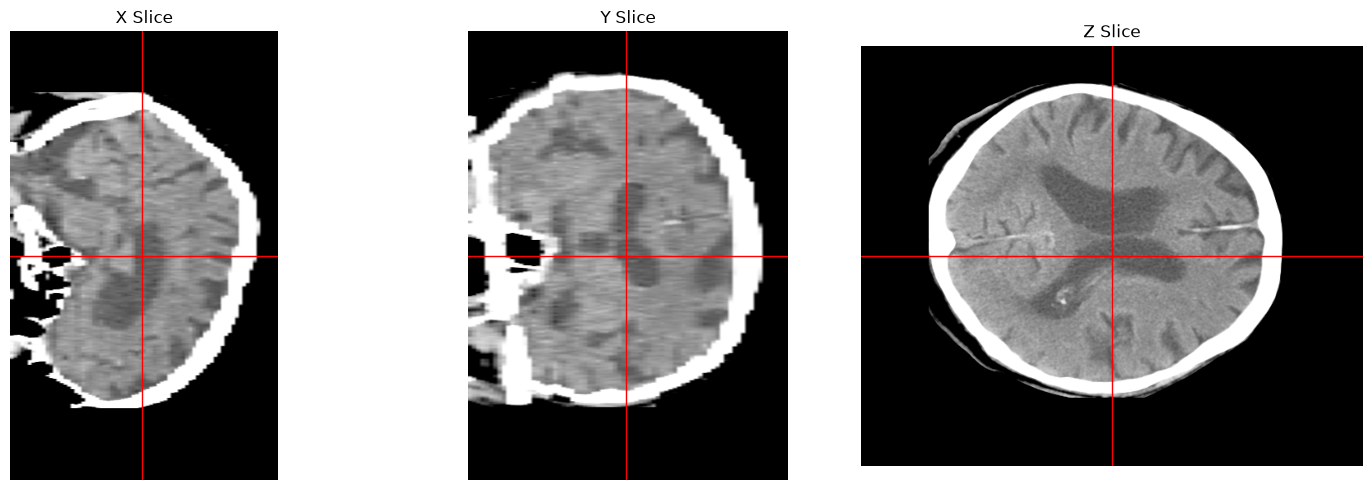

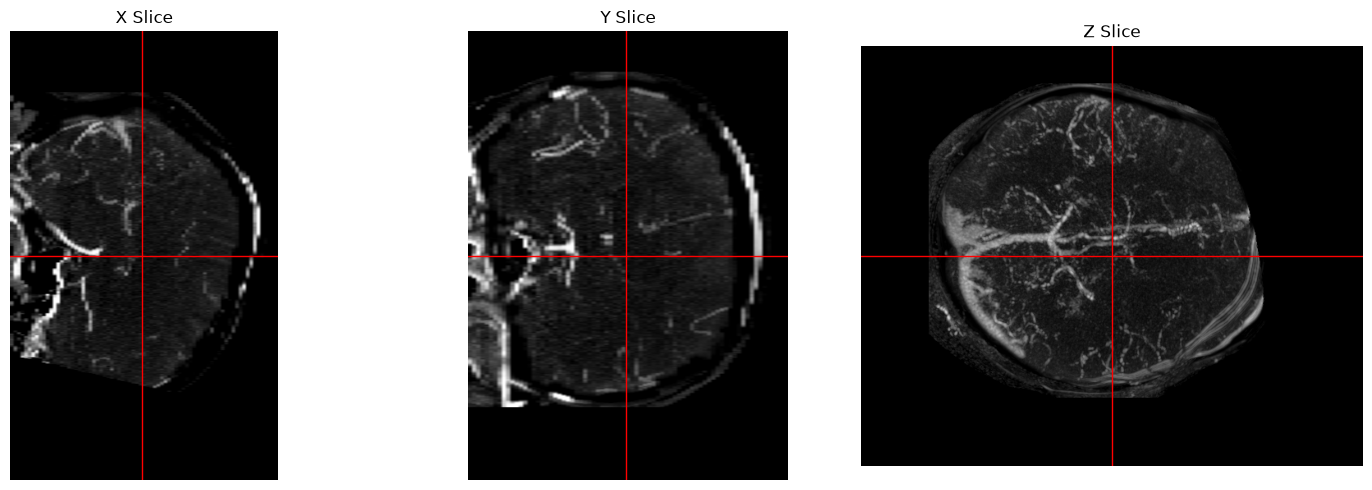

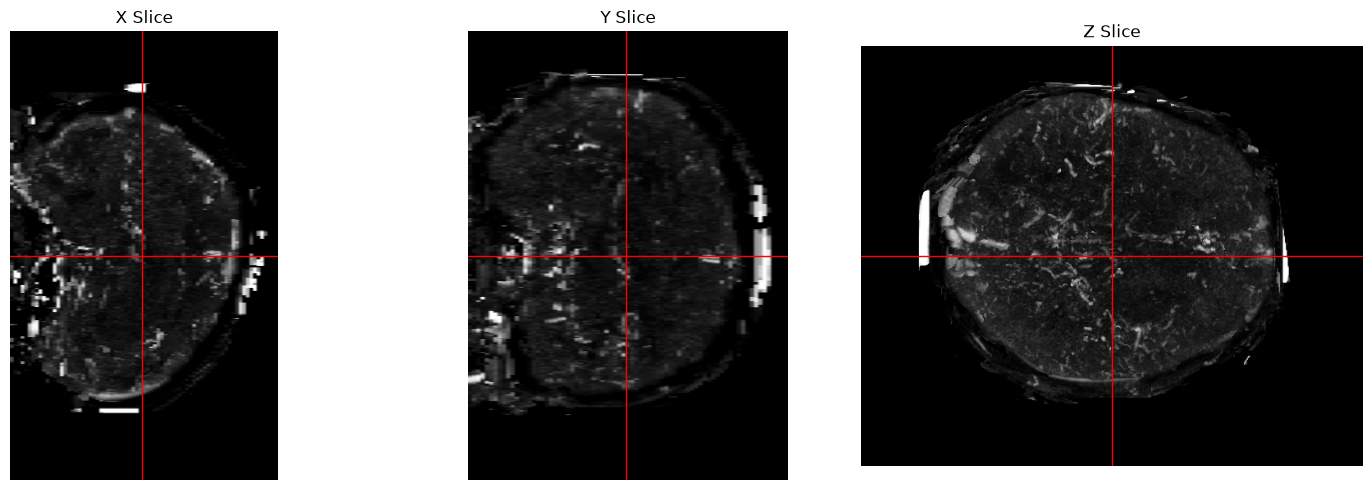

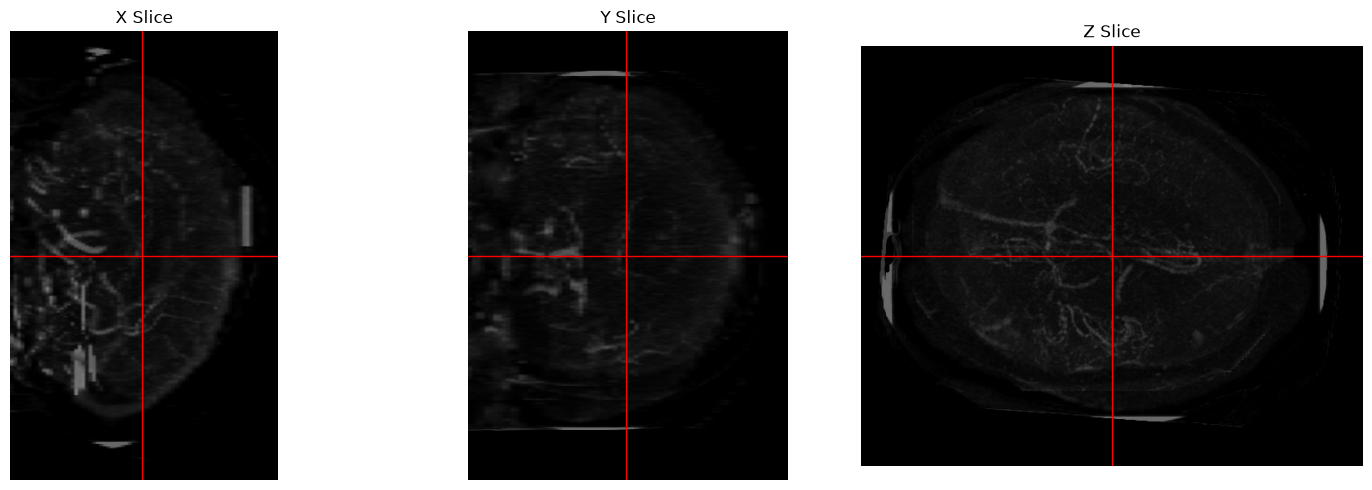

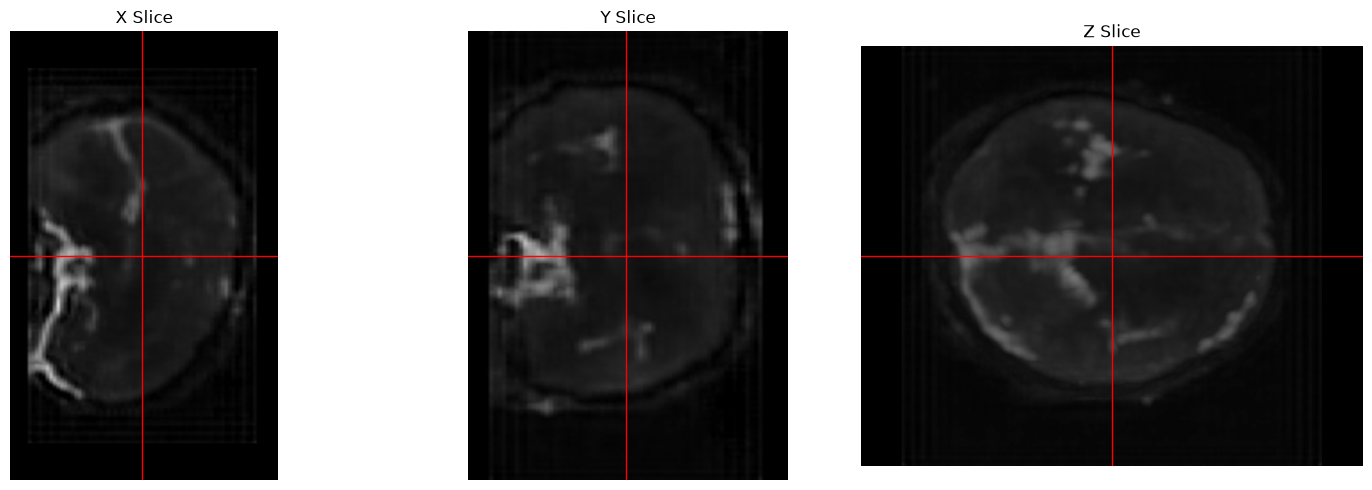

In [3]:
import matplotlib.pyplot as plt
from src.data import NiiPoint
slices = (0.5, 0.5 ,0.5)

for case_id in [12]:
    img_path = os.path.join("..", CONSTANTS.NORM_DATA_PATH_VAL_INP, f"case_{str(case_id).zfill(4)}_0000.nii.gz")
    lab_path = os.path.join("..", CONSTANTS.NORM_DATA_PATH_VAL_OUT, f"case_{str(case_id).zfill(4)}_0001.nii.gz")
    
    paths = [img_path, lab_path]
    names = ["ncct", "cta"]
    for model in ["cknn", "knn", "durag"]:
        output_dir = os.path.join("../data/Predictions_val", f"images_norm_{model}")
        paths.append(os.path.join(output_dir, f"case_{str(case_id).zfill(4)}_0001.nii.gz"))
        names.append(model)
    
    for i, (path, name) in enumerate(zip(paths, names)):
        img_nii = NiiPoint.from_path(path, "cuda")
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        thicks = (1, 1, 1) if i == 0 else (10, 10, 10) # no thickness for the input image
        img_nii.plot_slices_nii(slices, thicks, axes=axes, cmap="Greys_r", vmin=-1, vmax=1)
        plt.gcf().savefig(f"../figures/vessel_{str(case_id).zfill(4)}_{name}.png", bbox_inches="tight")
